In [9]:
import numpy as np
def equal_width_binning(data, num_bins=4):
    data = np.array(data)
    min_val = np.min(data)
    max_val = np.max(data)
    bins = np.linspace(min_val, max_val, num_bins + 1)
    binned_data = np.digitize(data, bins[:-1], right=False) - 1
    binned_data = np.clip(binned_data, 0, num_bins - 1)
    return binned_data, bins
def calculate_entropy(y):
    y = np.array(y)
    if len(y) == 0:
        return 0.0
    _, counts = np.unique(y, return_counts=True)
    probabilities = counts / len(y)
    entropy = -np.sum(probabilities * np.log2(probabilities + 1e-9))
    return entropy
dataset_labels = np.array([0] * 200 + [1] * 200)
total_entropy = calculate_entropy(dataset_labels)
print(f"Entropy of the Deepfake Dataset Labels: {total_entropy:.4f}")

Entropy of the Deepfake Dataset Labels: 1.0000


In [11]:
import numpy as np
def calculate_gini_index(y):
    y = np.array(y)
    if len(y) == 0:
        return 0.0
    _, counts = np.unique(y, return_counts=True)
    probabilities = counts / len(y)
    gini = 1.0 - np.sum(probabilities ** 2)
    return gini
dataset_labels = np.array([0] * 200 + [1] * 200)
gini_value = calculate_gini_index(dataset_labels)
print(f"Gini Index of the Deepfake Dataset: {gini_value:.4f}")

Gini Index of the Deepfake Dataset: 0.5000


In [13]:
import numpy as np
def calculate_entropy(y):
    y = np.array(y)
    if len(y) == 0:
        return 0.0
    _, counts = np.unique(y, return_counts=True)
    probabilities = counts / len(y)
    return -np.sum(probabilities * np.log2(probabilities + 1e-9))
def compute_information_gain(X_column, y, num_bins=4):
    y = np.array(y)
    X_column = np.array(X_column)
    parent_entropy = calculate_entropy(y)
    total_count = len(y)
    if np.issubdtype(X_column.dtype, np.number) and len(np.unique(X_column)) > num_bins:
        min_val, max_val = np.min(X_column), np.max(X_column)
        bins = np.linspace(min_val, max_val, num_bins + 1)
        X_column = np.digitize(X_column, bins[:-1], right=False) - 1
        X_column = np.clip(X_column, 0, num_bins - 1)
    unique_values = np.unique(X_column)
    child_entropy_sum = 0.0
    for val in unique_values:
        subset_y = y[X_column == val]
        weight = len(subset_y) / total_count
        child_entropy_sum += weight * calculate_entropy(subset_y)
    info_gain = parent_entropy - child_entropy_sum
    return info_gain
def find_root_node(X, y):
    X = np.array(X)
    num_features = X.shape[1]
    best_feature_idx = -1
    max_info_gain = -1.0
    gains = []
    for i in range(num_features):
        gain = compute_information_gain(X[:, i], y)
        gains.append(gain)
        if gain > max_info_gain:
            max_info_gain = gain
            best_feature_idx = i
    return best_feature_idx, max_info_gain, gains
np.random.seed(42)
mock_features = np.random.rand(400, 3) 
dataset_labels = np.array([0] * 200 + [1] * 200)
root_idx, best_gain, all_gains = find_root_node(mock_features, dataset_labels)
print(f"Information Gains for all features: {all_gains}")
print(f"Selected Root Node Feature Index: Feature {root_idx} with Information Gain of {best_gain:.4f}")

Information Gains for all features: [0.003160738229026294, 0.008972989420413136, 0.0001854954822062549]
Selected Root Node Feature Index: Feature 1 with Information Gain of 0.0090


In [15]:
import numpy as np
def custom_binning(data, binning_type='width', num_bins=4):
    data = np.array(data)
    if len(data) == 0:
        return np.array([]), np.array([])
    binning_type = binning_type.lower()
    if binning_type == 'width':
        min_val = np.min(data)
        max_val = np.max(data)
        if min_val == max_val:
            bins = np.array([min_val, max_val + 1.0])
            binned_data = np.zeros(len(data), dtype=int)
            return binned_data, bins
        bins = np.linspace(min_val, max_val, num_bins + 1)
        binned_data = np.digitize(data, bins[:-1], right=False) - 1
        binned_data = np.clip(binned_data, 0, num_bins - 1)
    elif binning_type == 'frequency':
        percentiles = np.linspace(0, 100, num_bins + 1)
        bins = np.percentile(data, percentiles)
        bins = np.unique(bins)
        if len(bins) <= 1:
            binned_data = np.zeros(len(data), dtype=int)
            return binned_data, bins
        binned_data = np.digitize(data, bins[1:-1], right=False)
        binned_data = np.clip(binned_data, 0, len(bins) - 2)
    else:
        raise ValueError("binning_type must be either 'width' or 'frequency'")
    return binned_data, bins
sample_feature_values = [1.2, 1.5, 2.0, 2.2, 5.0, 8.4, 9.1, 12.0, 18.5, 22.0]
binned_default, edges_default = custom_binning(sample_feature_values)
print(f"Default Binning (Width): {binned_default}")
binned_width, edges_width = custom_binning(sample_feature_values, binning_type='width', num_bins=4)
print(f"Equal-Width Binned Data: {binned_width}")
print(f"Equal-Width Bin Edges: {edges_width}\n")
binned_freq, edges_freq = custom_binning(sample_feature_values, binning_type='frequency', num_bins=4)
print(f"Equal-Frequency Binned Data: {binned_freq}")
print(f"Equal-Frequency Bin Edges (Percentiles): {edges_freq}")

Default Binning (Width): [0 0 0 0 0 1 1 2 3 3]
Equal-Width Binned Data: [0 0 0 0 0 1 1 2 3 3]
Equal-Width Bin Edges: [ 1.2  6.4 11.6 16.8 22. ]

Equal-Frequency Binned Data: [0 0 0 1 1 2 2 3 3 3]
Equal-Frequency Bin Edges (Percentiles): [ 1.2    2.05   6.7   11.275 22.   ]


In [17]:
import numpy as np
class CustomDecisionTreeNode:
    def __init__(self, feature_idx=None, threshold=None, left=None, right=None, *, value=None):
        self.feature_idx = feature_idx 
        self.threshold = threshold      
        self.left = left                
        self.right = right              
        self.value = value              
    @property
    def is_leaf(self):
        return self.value is not None
class CustomDecisionTreeClassifier:
    def __init__(self, max_depth=3, num_bins=4, binning_type='width'):
        self.max_depth = max_depth
        self.num_bins = num_bins
        self.binning_type = binning_type
        self.root = None
    def _calculate_entropy(self, y):
        y = np.array(y)
        if len(y) == 0:
            return 0.0
        _, counts = np.unique(y, return_counts=True)
        probabilities = counts / len(y)
        return -np.sum(probabilities * np.log2(probabilities + 1e-9))
    def _custom_binning(self, data):
        data = np.array(data)
        min_val, max_val = np.min(data), np.max(data)
        if min_val == max_val:
            return np.zeros(len(data), dtype=int), min_val
        if self.binning_type == 'width':
            bins = np.linspace(min_val, max_val, self.num_bins + 1)
            binned = np.digitize(data, bins[:-1], right=False) - 1
            return np.clip(binned, 0, self.num_bins - 1), bins
        elif self.binning_type == 'frequency':
            percentiles = np.linspace(0, 100, self.num_bins + 1)
            bins = np.percentile(data, percentiles)
            bins = np.unique(bins)
            if len(bins) <= 1:
                return np.zeros(len(data), dtype=int), bins
            binned = np.digitize(data, bins[1:-1], right=False)
            return np.clip(binned, 0, len(bins) - 2), bins
        return data, None
    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        self.root = self._build_tree(X, y, depth=0)
    def _build_tree(self, X, y, depth):
        num_samples, num_features = X.shape
        unique_labels = np.unique(y)
        if len(unique_labels) == 1 or depth >= self.max_depth or num_samples == 0:
            leaf_value = unique_labels[np.argmax(np.bincount(y))] if len(y) > 0 else 0
            return CustomDecisionTreeNode(value=leaf_value)
        parent_entropy = self._calculate_entropy(y)
        best_gain = -1.0
        split_idx, split_threshold = None, None
        best_binned_X = None
        for feat_idx in range(num_features):
            X_column = X[:, feat_idx]
            binned_col, threshold = self._custom_binning(X_column)
            unique_bins = np.unique(binned_col)
            child_entropy_sum = 0.0
            for b in unique_bins:
                subset_y = y[binned_col == b]
                weight = len(subset_y) / num_samples
                child_entropy_sum += weight * self._calculate_entropy(subset_y)
            gain = parent_entropy - child_entropy_sum
            if gain > best_gain:
                best_gain = gain
                split_idx = feat_idx
                split_threshold = threshold
                best_binned_X = binned_col
        if best_gain <= 0.0 or split_idx is None:
            leaf_value = unique_labels[np.argmax(np.bincount(y))]
            return CustomDecisionTreeNode(value=leaf_value)
        unique_bins = np.unique(best_binned_X)
        median_bin = np.median(unique_bins)
        left_mask = best_binned_X <= median_bin
        right_mask = ~left_mask
        left_child = self._build_tree(X[left_mask, :], y[left_mask], depth + 1)
        right_child = self._build_tree(X[right_mask, :], y[right_mask], depth + 1)
        return CustomDecisionTreeNode(feature_idx=split_idx, threshold=median_bin, left=left_child, right=right_child)
    def _predict_row(self, node, row):
        if node.is_leaf:
            return node.value
        val = row[node.feature_idx]
        return self._predict_row(node.left, row) if val <= node.threshold else self._predict_row(node.right, row)
    def predict(self, X):
        X = np.array(X)
        return np.array([self._predict_row(self.root, row) for row in X])
np.random.seed(42)
X_train = np.random.rand(400, 4)  
y_train = np.array([0] * 200 + [1] * 200) 
tree = CustomDecisionTreeClassifier(max_depth=3, num_bins=4, binning_type='width')
tree.fit(X_train, y_train)
predictions = tree.predict(X_train[:10])
print(f"Sample Predictions from Custom Decision Tree: {predictions}")
print("Decision Tree successfully built and evaluated!")

Sample Predictions from Custom Decision Tree: [0 0 0 0 0 0 0 0 0 0]
Decision Tree successfully built and evaluated!


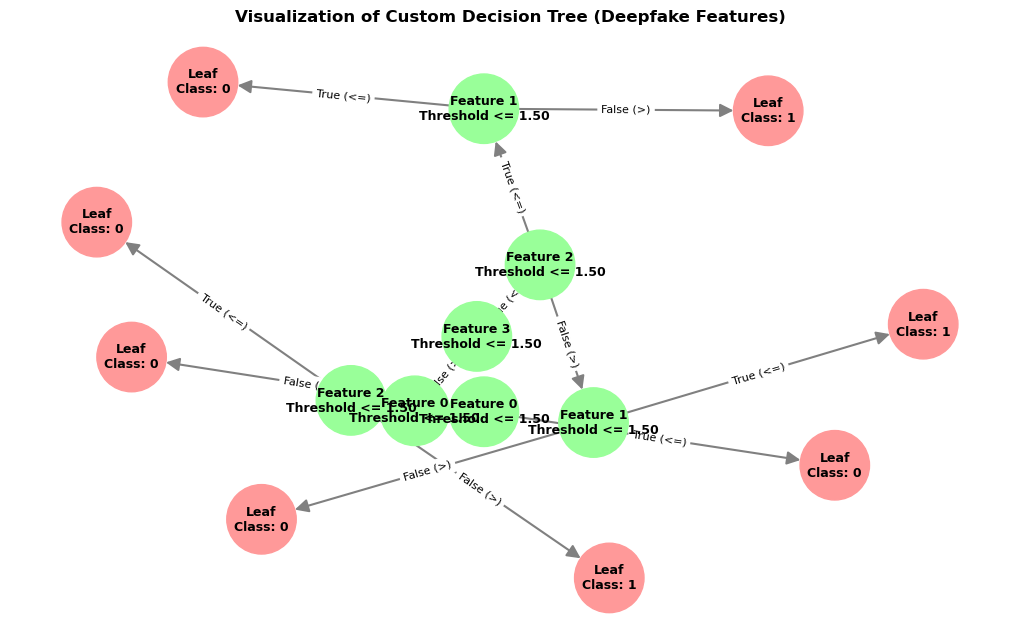

In [19]:
import matplotlib.pyplot as plt
import networkx as nx
def visualize_custom_tree(node, graph=None, parent_name=None, edge_label=""):
    if graph is None:
        graph = nx.DiGraph()
    node_id = str(id(node))
    if node.is_leaf:
        label = f"Leaf\nClass: {node.value}"
        color = '#ff9999' 
    else:
        label = f"Feature {node.feature_idx}\nThreshold <= {node.threshold:.2f}"
        color = '#99ff99' 
    graph.add_node(node_id, label=label, color=color)
    if parent_name is not None:
        graph.add_edge(parent_name, node_id, label=edge_label)
    if node.left is not None:
        visualize_custom_tree(node.left, graph, node_id, edge_label="True (<=)")
    if node.right is not None:
        visualize_custom_tree(node.right, graph, node_id, edge_label="False (>)")  
    return graph
dt_graph = visualize_custom_tree(tree.root)
plt.figure(figsize=(10, 6))
pos = nx.spring_layout(dt_graph, seed=42) # Or use hierarchy layouts if available
node_labels = nx.get_node_attributes(dt_graph, 'label')
node_colors = [data['color'] for _, data in dt_graph.nodes(data=True)]
edge_labels = nx.get_edge_attributes(dt_graph, 'label')
nx.draw(dt_graph, pos, with_labels=False, node_color=node_colors, node_size=2500, edge_color='gray', width=1.5, arrows=True, arrowsize=20)
nx.draw_networkx_labels(dt_graph, pos, labels=node_labels, font_size=9, font_weight='bold')
nx.draw_networkx_edge_labels(dt_graph, pos, edge_labels=edge_labels, font_size=8)
plt.title("Visualization of Custom Decision Tree (Deepfake Features)", fontsize=12, fontweight='bold')
plt.axis('off')
plt.show()

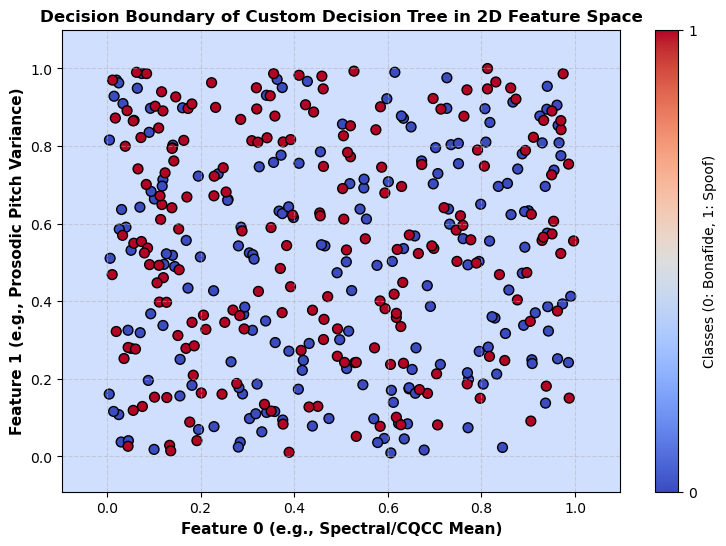

In [21]:
import matplotlib.pyplot as plt
import numpy as np
np.random.seed(42)
X_2d = np.random.rand(400, 2)  
y_labels = np.array([0] * 200 + [1] * 200) # 200 Bonafide (0) and 200 Spoof (1)
dt_2d = CustomDecisionTreeClassifier(max_depth=3, num_bins=4, binning_type='width')
dt_2d.fit(X_2d, y_labels)
x_min, x_max = X_2d[:, 0].min() - 0.1, X_2d[:, 0].max() + 0.1
y_min, y_max = X_2d[:, 1].min() - 0.1, X_2d[:, 1].max() + 0.1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
grid_points = np.c_[xx.ravel(), yy.ravel()]
grid_preds = dt_2d.predict(grid_points)
Z = grid_preds.reshape(xx.shape)
plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.coolwarm)
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_labels, edgecolors='k', cmap=plt.cm.coolwarm, s=50)
plt.xlabel("Feature 0 (e.g., Spectral/CQCC Mean)", fontsize=11, fontweight='bold')
plt.ylabel("Feature 1 (e.g., Prosodic Pitch Variance)", fontsize=11, fontweight='bold')
plt.title("Decision Boundary of Custom Decision Tree in 2D Feature Space", fontsize=12, fontweight='bold')
plt.colorbar(scatter, ticks=[0, 1], label="Classes (0: Bonafide, 1: Spoof)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [23]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np
np.random.seed(42)
X_data = np.random.rand(400, 4)  
y_labels = np.array([0] * 200 + [1] * 200)
base_clf = DecisionTreeClassifier(random_state=42)
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid_search = GridSearchCV(
    estimator=base_clf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_data, y_labels)
print("--- Hyper-parameter Tuning Results (GridSearchCV) ---")
print(f"Best Hyperparameters Found: {grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_ * 100:.2f}%")

--- Hyper-parameter Tuning Results (GridSearchCV) ---
Best Hyperparameters Found: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best Cross-Validation Accuracy: 55.00%
